In [2]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
dataset = load_dataset("PolyAI/banking77", trust_remote_code=True)

c:\Users\hongk\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'PolyAI/banking77' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
Using the latest cached version of the dataset since PolyAI/banking77 couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\hongk\.cache\huggingface\datasets\PolyAI___banking77\default\1.1.0\17ffc2ed47c2ed928bee64127ff1dbc97204cb974c2f980becae7c864007aed9 (last modified on Sun Apr 19 08:34:01 2026).


In [2]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 10003
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3080
    })
})


In [3]:
df_train = dataset['train'].to_pandas()
df_test = dataset['test'].to_pandas()


23
76


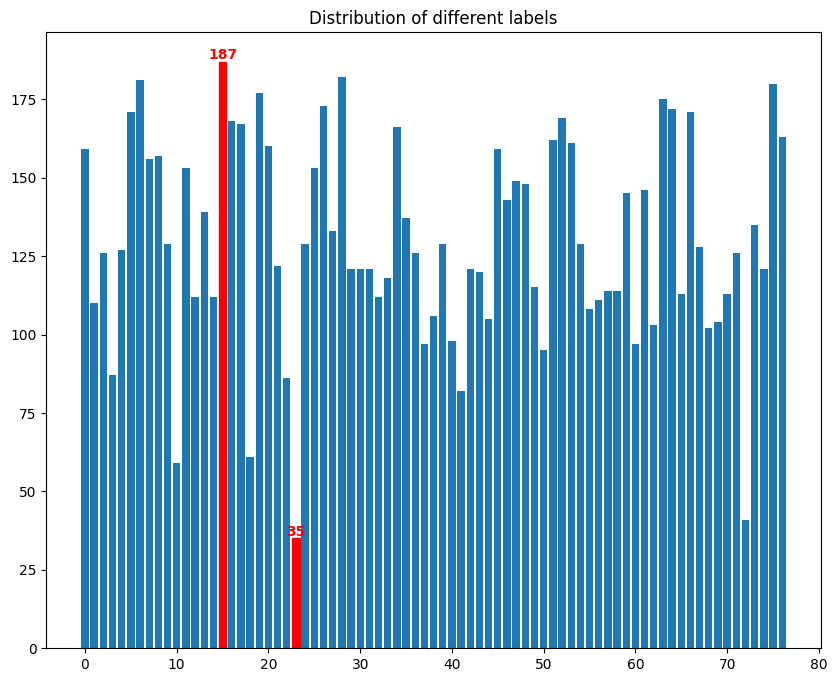

In [ ]:
val = df_train['label'].value_counts()

plt.figure(figsize=(10, 8))
plt.title("Distribution of different labels")
bars = plt.bar(val.index, val.values)

# Tìm vị trí của giá trị nhỏ nhất
min_index = val.values.argmin()
min_value = val.values[min_index]

max_index = val.values.argmax()
max_value = val.values[max_index]

# Tô màu đỏ cho cột nhỏ nhất
bars[min_index].set_color('red')
bars[max_index].set_color('red')
plt.xtitle("Hello")
pl
# Ghi chú giá trị lên trên cột nhỏ nhất
plt.text(val.index[min_index], min_value, str(min_value), ha='center', va='bottom', color='red', fontweight='bold')
plt.text(val.index[max_index], max_value, str(max_value), ha='center', va='bottom', color='red', fontweight='bold')
print(val.index[min_index])
print(min_index)

plt.show()

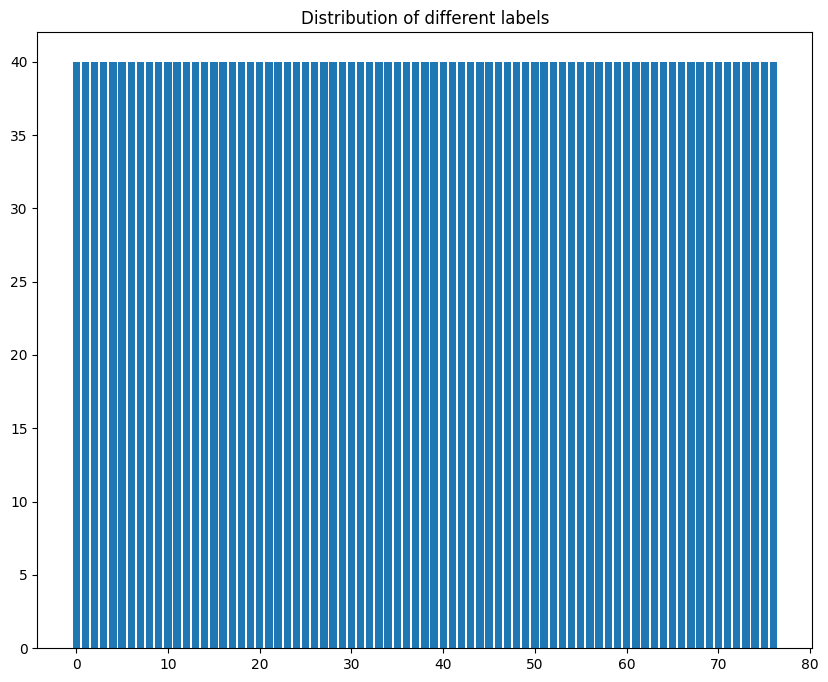

In [26]:
val = df_test['label'].value_counts()

plt.figure(figsize=(10, 8))
plt.title("Distribution of different labels")
plt.bar(val.index, val.values)
plt.show()

In [43]:
counts = {}

for text in df_train['text']:
    if len(text) not in counts.keys():
        counts[len(text)] = 1
    else:
        counts[len(text)] += 1

# Sắp xếp lại theo độ dài để dễ quan sát
sorted_counts = dict(sorted(counts.items()))
print(sorted_counts)

{13: 6, 14: 2, 15: 5, 16: 7, 17: 11, 18: 15, 19: 26, 20: 36, 21: 39, 22: 49, 23: 72, 24: 83, 25: 117, 26: 111, 27: 135, 28: 152, 29: 160, 30: 184, 31: 194, 32: 190, 33: 219, 34: 234, 35: 234, 36: 248, 37: 240, 38: 227, 39: 234, 40: 234, 41: 257, 42: 246, 43: 261, 44: 232, 45: 235, 46: 231, 47: 213, 48: 176, 49: 200, 50: 178, 51: 190, 52: 170, 53: 188, 54: 160, 55: 140, 56: 148, 57: 144, 58: 125, 59: 118, 60: 115, 61: 99, 62: 93, 63: 93, 64: 91, 65: 92, 66: 74, 67: 72, 68: 72, 69: 69, 70: 52, 71: 53, 72: 54, 73: 47, 74: 42, 75: 53, 76: 33, 77: 42, 78: 41, 79: 31, 80: 47, 81: 23, 82: 38, 83: 31, 84: 22, 85: 21, 86: 23, 87: 26, 88: 21, 89: 30, 90: 23, 91: 14, 92: 20, 93: 17, 94: 17, 95: 19, 96: 18, 97: 21, 98: 17, 99: 26, 100: 18, 101: 9, 102: 9, 103: 19, 104: 14, 105: 13, 106: 15, 107: 13, 108: 9, 109: 15, 110: 9, 111: 14, 112: 15, 113: 11, 114: 10, 115: 16, 116: 13, 117: 18, 118: 10, 119: 14, 120: 13, 121: 17, 122: 17, 123: 20, 124: 13, 125: 10, 126: 15, 127: 9, 128: 9, 129: 9, 130: 14,

In [49]:
# Xem trước những dòng chứa khoảng trắng thừa (newline, tab, nhiều space liên tiếp) \n
mask = df_train['text'].str.contains(r'\\s{2,}|\\n|\\t', regex=True)
df_train[mask].head()

,text,label


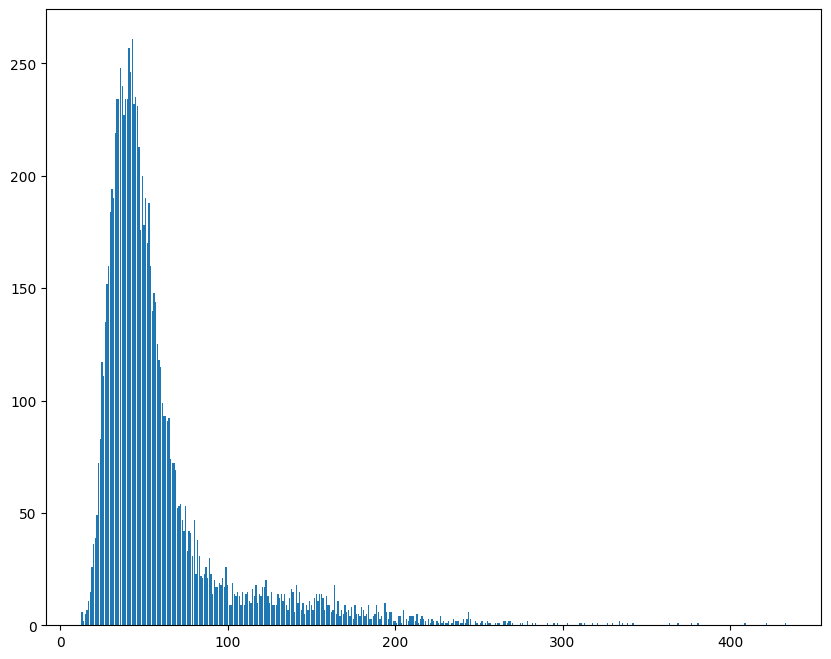

In [44]:
plt.figure(figsize=(10, 8))
plt.bar(counts.keys(), counts.values())
plt.show()

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


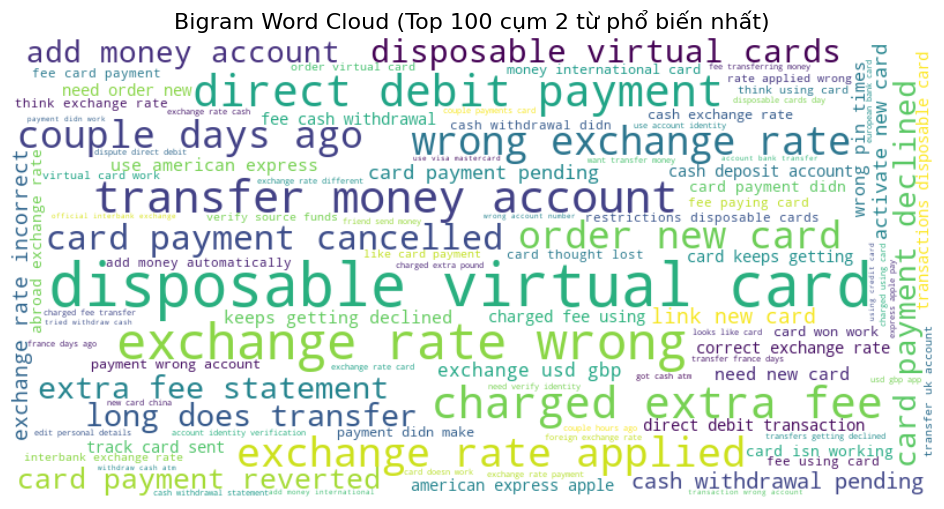

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Lấy danh sách văn bản cần đếm từ tập train
texts = df_train['text'].dropna().tolist()

# 1. & 2. Cấu hình CountVectorizer để tạo Bigram (cụm 2 từ), loại bỏ stop words tiếng Anh
# Lưu ý: Nếu muốn tạo Trigram (cụm 3 từ), hãy đổi thành ngram_range=(3, 3)
vectorizer = CountVectorizer(ngram_range=(3, 3), stop_words='english')

# Trích xuất đặc trưng và đếm
X = vectorizer.fit_transform(texts)

# 3. Tính tổng tần suất của mỗi Bigram trên toàn bộ tập văn bản
frequencies = sum(X).toarray()[0]
# Lấy danh sách các câu từ ghép tương ứng
ngrams = vectorizer.get_feature_names_out()

# Tạo Dictionary map giữa cụm n-gram và số lần xuất hiện
ngram_freq_dict = dict(zip(ngrams, frequencies))

# (Tùy chọn) Sắp xếp và chỉ lấy 100 cụm từ phổ biến nhất để Word Cloud không bị quá rối
top_ngrams = dict(sorted(ngram_freq_dict.items(), key=lambda item: item[1], reverse=True)[:100])

# 4. Tạo WordCloud từ dictionary tần suất
wordcloud = WordCloud(
    width=800, 
    height=400,
    background_color='white',
    colormap='viridis'  # Đổi bảng màu nếu muốn
).generate_from_frequencies(top_ngrams)

# 5. Trực quan hóa bằng matplotlib
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Tắt hiển thị trục toạ độ
plt.title("Bigram Word Cloud (Top 100 cụm 2 từ phổ biến nhất)", fontsize=16)
plt.show()

In [39]:
tuples = [('kien', 1), ('loa', 3), ('kevien', 4)]
print(tuples)
dict_tup = dict(tuples)
print(dict_tup)
print(dict_tup.items())

frequent = [1, 2, 3, 4]
name = ['kien', 'bao', 'quan', 'ha']

lst = dict(zip(name, frequent))
print(lst)

[('kien', 1), ('loa', 3), ('kevien', 4)]
{'kien': 1, 'loa': 3, 'kevien': 4}
dict_items([('kien', 1), ('loa', 3), ('kevien', 4)])
{'kien': 1, 'bao': 2, 'quan': 3, 'ha': 4}


In [40]:
# Lấy đối tượng định dạng nhãn gốc từ dataset train
label_feature = dataset['train'].features['label']

# Lấy danh sách toàn bộ dạng CHỮ (names) của 77 nhãn
# Lưu ý: Index (vị trí) của chữ trong mảng này chính là số hiệu ID của nó.
# Ví dụ: mảng[0] sẽ ra tên nhãn của số 0.
label_names = label_feature.names

# -- CÁCH 1: Tạo Dictionary mapping từ SỐ sang CHỮ --
id2label = {idx: name for idx, name in enumerate(label_names)}

# -- CÁCH 2: Tạo Dictionary mapping từ CHỮ sang SỐ (ngược lại) --
label2id = {name: idx for idx, name in enumerate(label_names)}

# -- VÍ DỤ SỬ DỤNG --
print("Nhãn chữ của số 0 là:", id2label[0])
print("Mã số của nhãn 'card_arrival' là:", label2id['card_arrival'])

Nhãn chữ của số 0 là: activate_my_card
Mã số của nhãn 'card_arrival' là: 11


151.89999999999964


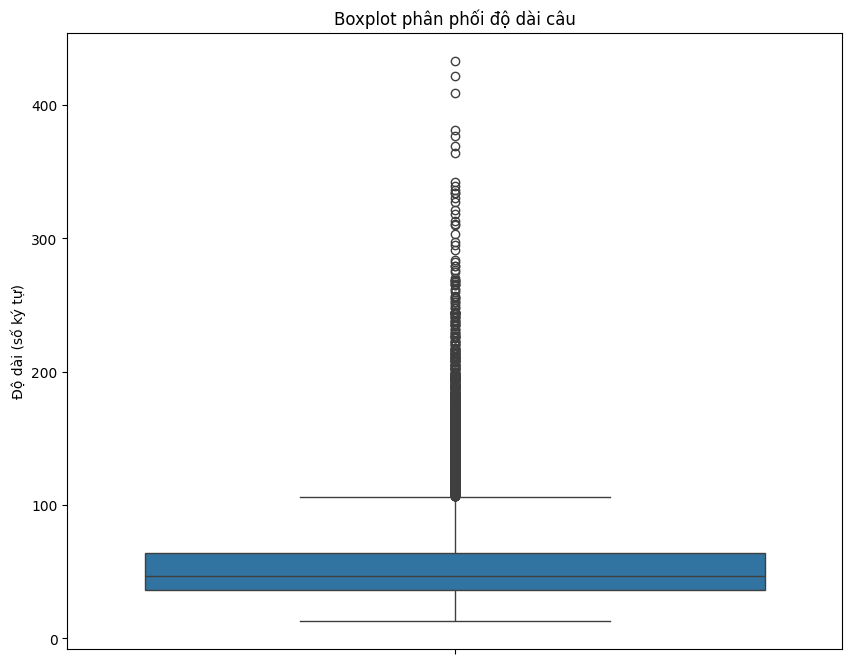

In [45]:
# Lấy ra độ dài mà 95% dữ liệu đều ngắn hơn hoặc bằng mức này
print(df_train['text'].apply(len).quantile(0.95))


import seaborn as sns

plt.figure(figsize=(10,8))
sns.boxplot(y=df_train['text'].apply(len))
plt.title("Boxplot phân phối độ dài câu")
plt.ylabel("Độ dài (số ký tự)")
plt.show()

In [ ]:
from FlagEmbedding import BGEM3FlagModel

model = BGEM3FlagModel('BAAI/bge-m3', use_fp16=True)
sentences = ["Sample text for embedding."]




c:\Users\hongk\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipping import of cpp extensions due to incompatible torch version 2.9.1+cpu for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info
W0421 08:19:59.112000 4948 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
Fetching 30 files: 100%|██████████| 30/30 [00:00<?, ?it/s]
You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


In [ ]:
embeddings = model.encode(sentences)['dense_vecs']
print(embeddings)

{'dense_vecs': array([[-0.05673692,  0.01364323, -0.01904791, ...,  0.01644168,
        -0.05007086, -0.00176904]], dtype=float32), 'lexical_weights': None, 'colbert_vecs': None}
